In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('play_by_play_2023.csv', low_memory=False)

print("Shape:", df.shape)
print(df.head())
print(df.columns.tolist())

FileNotFoundError: [Errno 2] No such file or directory: 'play_by_play_2023.csv'

In [2]:
import os
print(os.getcwd())  # batayega notebook kahan hai

C:\Users\Hameed Computers


In [3]:
df = pd.read_csv('play_by_play_2023.csv', low_memory=False)
print("Shape:", df.shape)
print(df.head())

FileNotFoundError: [Errno 2] No such file or directory: 'play_by_play_2023.csv'

In [4]:
df = pd.read_csv(r'C:\Users\Hameed Computers\Downloads\play_by_play_2023.csv', low_memory=False)
print("Shape:", df.shape)

Shape: (49665, 372)


In [5]:
print(df.head())
print(df.columns)
print(df.isnull().sum())

   play_id          game_id  old_game_id home_team away_team season_type  \
0        1  2023_01_ARI_WAS   2023091007       WAS       ARI         REG   
1       39  2023_01_ARI_WAS   2023091007       WAS       ARI         REG   
2       55  2023_01_ARI_WAS   2023091007       WAS       ARI         REG   
3       77  2023_01_ARI_WAS   2023091007       WAS       ARI         REG   
4      102  2023_01_ARI_WAS   2023091007       WAS       ARI         REG   

   week posteam posteam_type defteam  ... out_of_bounds  home_opening_kickoff  \
0     1     NaN          NaN     NaN  ...             0                     1   
1     1     WAS         home     ARI  ...             0                     1   
2     1     WAS         home     ARI  ...             0                     1   
3     1     WAS         home     ARI  ...             0                     1   
4     1     WAS         home     ARI  ...             0                     1   

     qb_epa  xyac_epa  xyac_mean_yardage  xyac_median_ya

In [6]:
# Date column fix karo
df['game_date'] = pd.to_datetime(df['game_date'], errors='coerce')

# Important columns select karo (sab 372 use nahi hongi)
important_cols = [
    'game_date', 'week', 'season_type', 'home_team', 'away_team',
    'posteam', 'defteam', 'play_type', 'yards_gained', 'qtr', 'down',
    'ydstogo', 'score_differential', 'touchdown', 'interception',
    'sack', 'pass_attempt', 'rush_attempt', 'epa', 'wp',
    'pass_length', 'pass_location', 'run_location', 'field_goal_result',
    'home_score', 'away_score', 'roof', 'stadium', 'qb_epa'
]

df_clean = df[important_cols].copy()

# Nulls clean karo
df_clean['yards_gained'] = df_clean['yards_gained'].fillna(0)
df_clean['down'] = df_clean['down'].fillna(0).astype(int)
df_clean['score_differential'] = df_clean['score_differential'].fillna(0)
df_clean['epa'] = df_clean['epa'].fillna(0)
df_clean['wp'] = df_clean['wp'].fillna(0)

# Play type nulls hatao
df_clean = df_clean.dropna(subset=['play_type', 'posteam'])

print("✅ Clean data shape:", df_clean.shape)
print("\nNull values remaining:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

✅ Clean data shape: (46160, 29)

Null values remaining:
touchdown               37
interception            37
sack                    37
pass_attempt            37
rush_attempt            37
pass_length          26976
pass_location        26976
run_location         31437
field_goal_result    45053
dtype: int64


In [7]:
# Style set karo
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (10, 5)
colors = sns.color_palette("Set2")

# ─────────────────────────────────────────
# CHART 1 — PIE CHART: Play Type Distribution
# ─────────────────────────────────────────
play_counts = df_clean['play_type'].value_counts()

fig, ax = plt.subplots()
ax.pie(play_counts, labels=play_counts.index, autopct='%1.1f%%',
       colors=sns.color_palette("Set2", len(play_counts)), startangle=90)
ax.set_title('🏈 Play Type Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart1_pie.png', dpi=150)
plt.show()
print("✅ Chart 1 done!")

# ─────────────────────────────────────────
# CHART 2 — HISTOGRAM: Yards Gained
# ─────────────────────────────────────────
fig, ax = plt.subplots()
ax.hist(df_clean['yards_gained'], bins=50, color=colors[1], edgecolor='white')
ax.set_title('📏 Yards Gained Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Yards Gained')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.savefig('chart2_histogram.png', dpi=150)
plt.show()
print("✅ Chart 2 done!")

# ─────────────────────────────────────────
# CHART 3 — LINE CHART: Avg Yards per Week
# ─────────────────────────────────────────
weekly_yards = df_clean.groupby('week')['yards_gained'].mean().reset_index()

fig, ax = plt.subplots()
ax.plot(weekly_yards['week'], weekly_yards['yards_gained'],
        mark

_IncompleteInputError: incomplete input (2873920489.py, line 40)

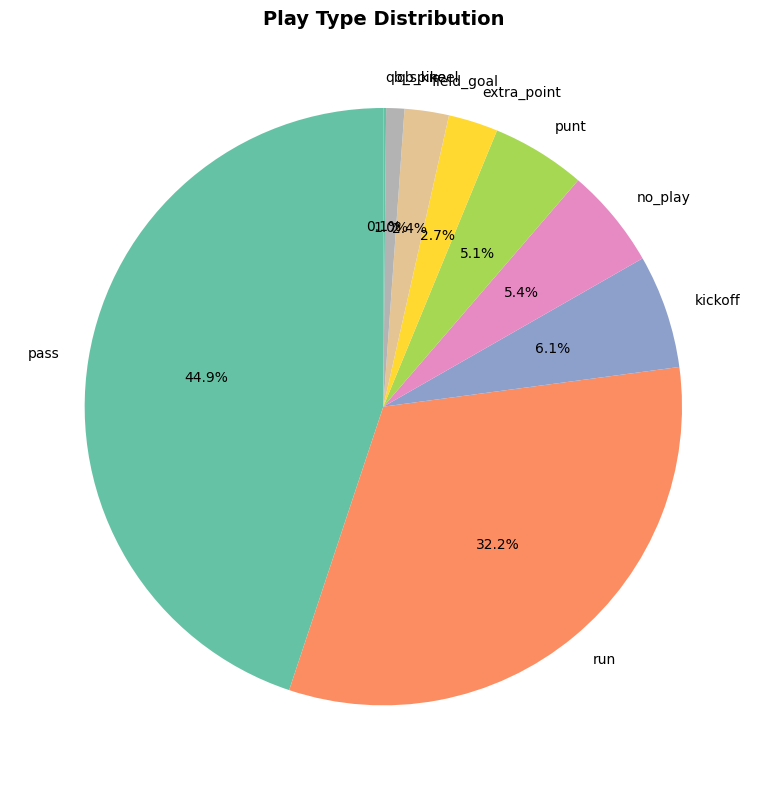

In [9]:
play_counts = df_clean['play_type'].value_counts()

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(play_counts, labels=play_counts.index, autopct='%1.1f%%',
       colors=sns.color_palette("Set2", len(play_counts)), startangle=90)
ax.set_title('Play Type Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart1_pie.png', dpi=150)
plt.show()

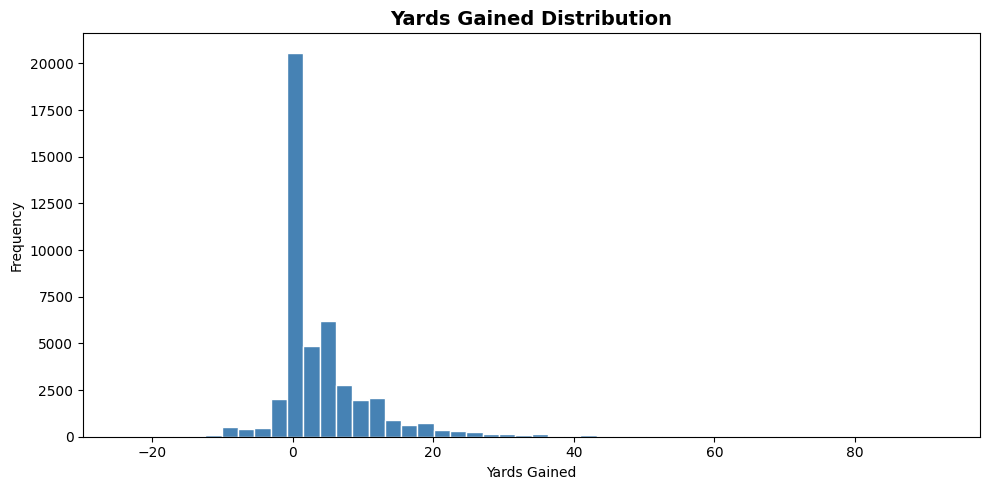

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_clean['yards_gained'], bins=50, color='steelblue', edgecolor='white')
ax.set_title('Yards Gained Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Yards Gained')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.savefig('chart2_histogram.png', dpi=150)
plt.show()

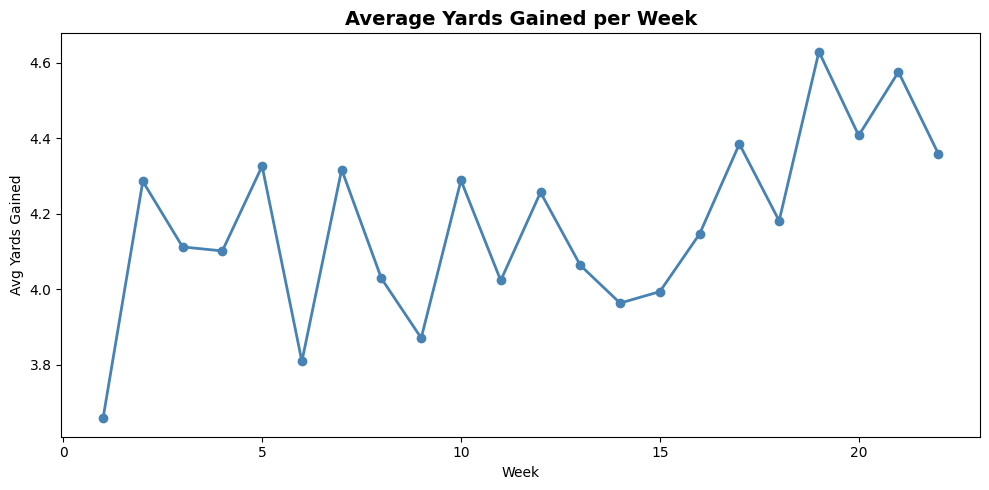

In [11]:
weekly_yards = df_clean.groupby('week')['yards_gained'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(weekly_yards['week'], weekly_yards['yards_gained'],
        marker='o', color='steelblue', linewidth=2)
ax.set_title('Average Yards Gained per Week', fontsize=14, fontweight='bold')
ax.set_xlabel('Week')
ax.set_ylabel('Avg Yards Gained')
plt.tight_layout()
plt.savefig('chart3_line.png', dpi=150)
plt.show()

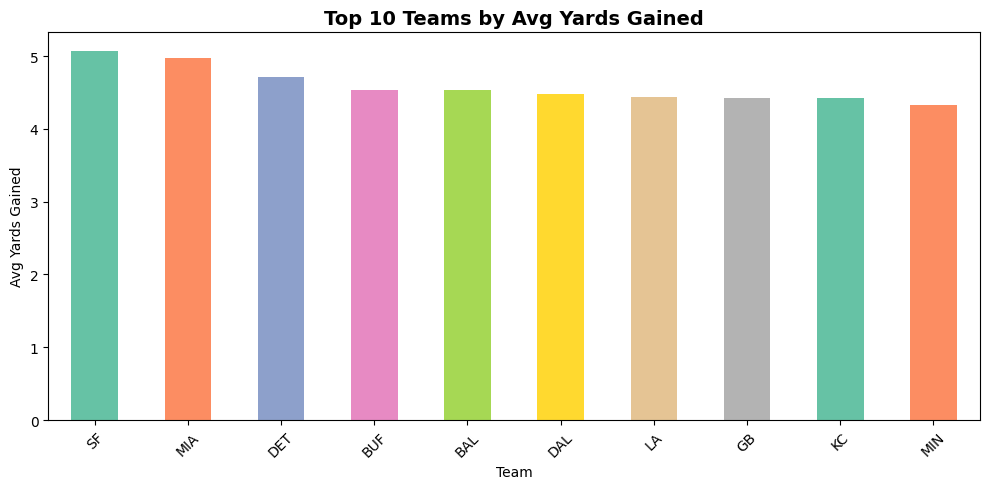

In [12]:
top_teams = df_clean.groupby('posteam')['yards_gained'].mean().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
top_teams.plot(kind='bar', ax=ax, color=sns.color_palette("Set2", 10))
ax.set_title('Top 10 Teams by Avg Yards Gained', fontsize=14, fontweight='bold')
ax.set_xlabel('Team')
ax.set_ylabel('Avg Yards Gained')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('chart4_bar.png', dpi=150)
plt.show()

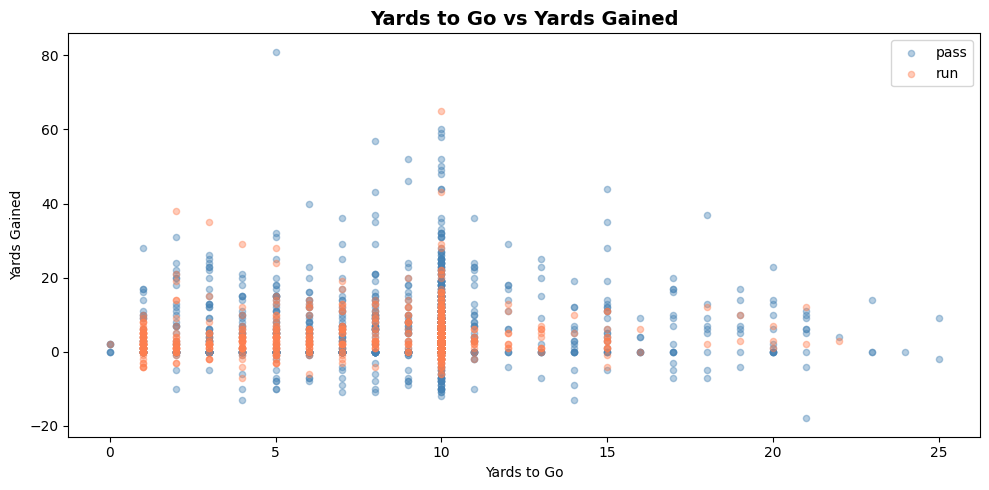

In [13]:
sample = df_clean[df_clean['play_type'].isin(['pass', 'run'])].sample(2000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 5))
for ptype, color in zip(['pass', 'run'], ['steelblue', 'coral']):
    subset = sample[sample['play_type'] == ptype]
    ax.scatter(subset['ydstogo'], subset['yards_gained'],
               alpha=0.4, label=ptype, color=color, s=20)
ax.set_title('Yards to Go vs Yards Gained', fontsize=14, fontweight='bold')
ax.set_xlabel('Yards to Go')
ax.set_ylabel('Yards Gained')
ax.legend()
plt.tight_layout()
plt.savefig('chart5_scatter.png', dpi=150)
plt.show()

C:\Users\Hameed Computers\AppData\Local\Temp\ipykernel_12996\3628878913.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=box_data, x='play_type', y='yards_gained',


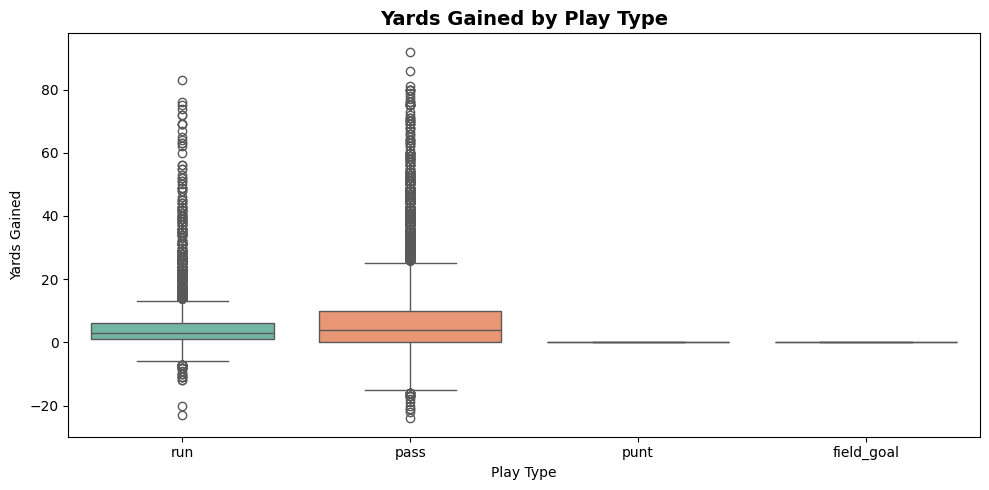

In [14]:
box_data = df_clean[df_clean['play_type'].isin(['pass', 'run', 'punt', 'field_goal'])]

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=box_data, x='play_type', y='yards_gained',
            palette='Set2', ax=ax)
ax.set_title('Yards Gained by Play Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Play Type')
ax.set_ylabel('Yards Gained')
plt.tight_layout()
plt.savefig('chart6_box.png', dpi=150)
plt.show()

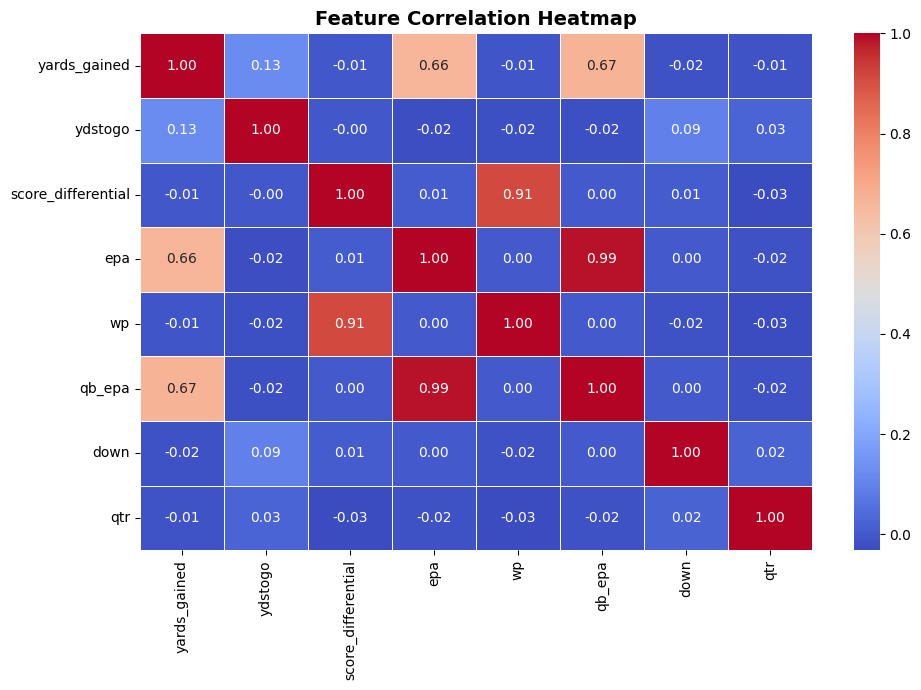

In [15]:
corr_cols = ['yards_gained', 'ydstogo', 'score_differential', 'epa', 'wp', 'qb_epa', 'down', 'qtr']
corr_matrix = df_clean[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart7_heatmap.png', dpi=150)
plt.show()

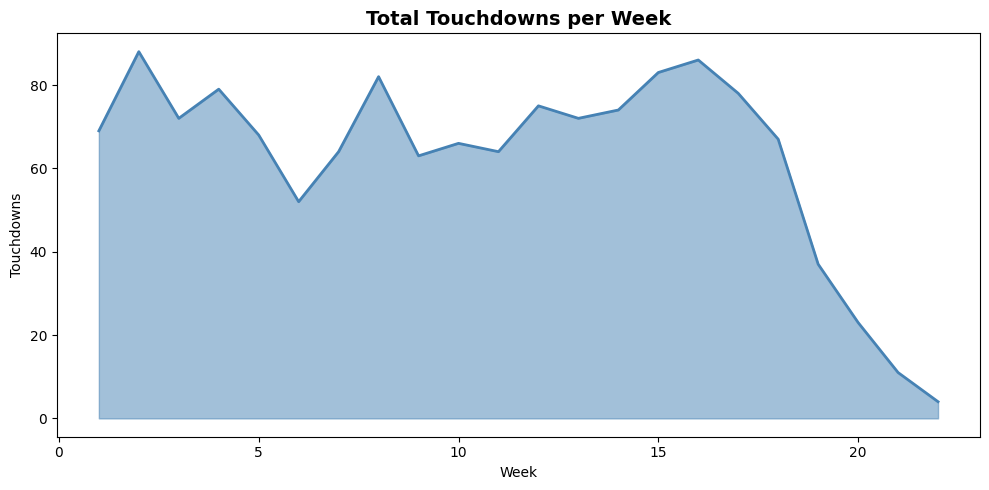

In [16]:
weekly_tds = df_clean.groupby('week')['touchdown'].sum().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(weekly_tds['week'], weekly_tds['touchdown'],
                color='steelblue', alpha=0.5)
ax.plot(weekly_tds['week'], weekly_tds['touchdown'],
        color='steelblue', linewidth=2)
ax.set_title('Total Touchdowns per Week', fontsize=14, fontweight='bold')
ax.set_xlabel('Week')
ax.set_ylabel('Touchdowns')
plt.tight_layout()
plt.savefig('chart8_area.png', dpi=150)
plt.show()

C:\Users\Hameed Computers\AppData\Local\Temp\ipykernel_12996\3517401642.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='qtr', palette='Set2', ax=ax)


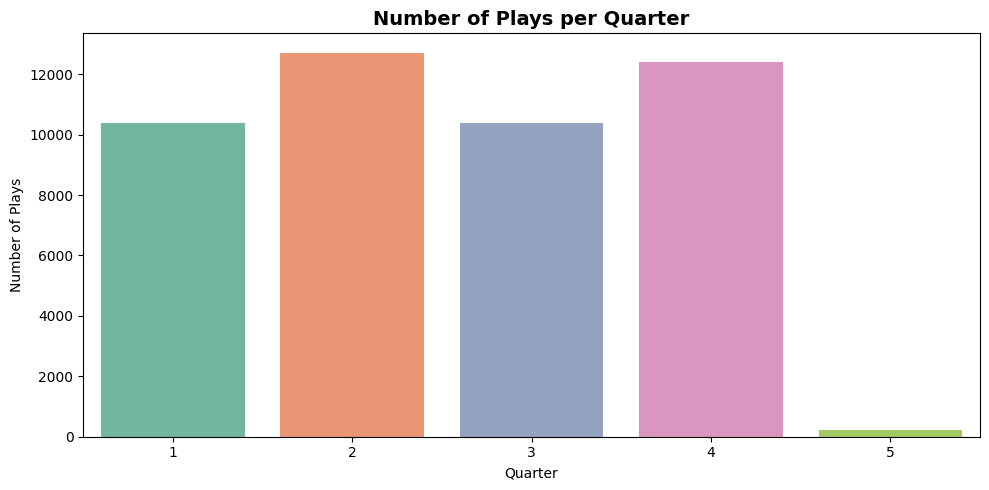

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(data=df_clean, x='qtr', palette='Set2', ax=ax)
ax.set_title('Number of Plays per Quarter', fontsize=14, fontweight='bold')
ax.set_xlabel('Quarter')
ax.set_ylabel('Number of Plays')
plt.tight_layout()
plt.savefig('chart9_countplot.png', dpi=150)
plt.show()

C:\Users\Hameed Computers\AppData\Local\Temp\ipykernel_12996\264488468.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=violin_data, x='play_type', y='yards_gained',


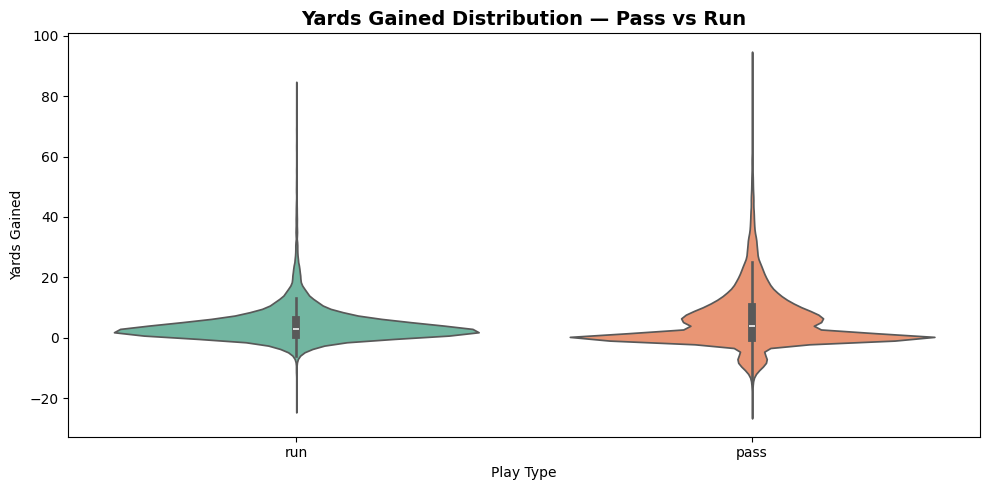

In [18]:
violin_data = df_clean[df_clean['play_type'].isin(['pass', 'run'])]

fig, ax = plt.subplots(figsize=(10, 5))
sns.violinplot(data=violin_data, x='play_type', y='yards_gained',
               palette='Set2', ax=ax)
ax.set_title('Yards Gained Distribution — Pass vs Run', fontsize=14, fontweight='bold')
ax.set_xlabel('Play Type')
ax.set_ylabel('Yards Gained')
plt.tight_layout()
plt.savefig('chart10_violin.png', dpi=150)
plt.show()

In [19]:
import os
print("📂 Current folder:", os.getcwd())

📂 Current folder: C:\Users\Hameed Computers


In [21]:

import pandas as pd
import streamlit as st

@st.cache_data
def load_data():
    df = pd.read_csv("play_by_play_2023.csv", low_memory=False)
    df["game_date"] = pd.to_datetime(df["game_date"], errors="coerce")
    df["down"] = df["down"].fillna(0).astype(int)
    df["week"] = df["week"].astype(int)
    important_cols = [
        "game_date", "week", "season_type", "home_team", "away_team",
        "posteam", "defteam", "play_type", "yards_gained", "qtr", "down",
        "ydstogo", "score_differential", "touchdown", "interception",
        "sack", "pass_attempt", "rush_attempt", "epa", "wp",
        "pass_length", "pass_location", "run_location", "field_goal_result",
        "home_score", "away_score", "roof", "stadium", "qb_epa"
    ]
    df = df[important_cols].copy()
    df["yards_gained"] = df["yards_gained"].fillna(0)
    df["score_differential"] = df["score_differential"].fillna(0)
    df["epa"] = df["epa"].fillna(0)
    df["wp"] = df["wp"].fillna(0)
    df = df.dropna(subset=["play_type", "posteam"])
    return df

def apply_filters(df):
    st.sidebar.header("🔎 Filters")

    # 1. Date Range
    min_date = df["game_date"].min().date()
    max_date = df["game_date"].max().date()
    date_range = st.sidebar.date_input("📅 Date Range",
        value=(min_date, max_date),
        min_value=min_date, max_value=max_date)
    if isinstance(date_range, (list, tuple)) and len(date_range) == 2:
        df = df[(df["game_date"] >= pd.Timestamp(date_range[0])) &
                (df["game_date"] <= pd.Timestamp(date_range[1]))]

    # 2. Season Type
    season_types = sorted(df["season_type"].dropna().unique().tolist())
    selected_season = st.sidebar.selectbox("🏟️ Season Type", ["All"] + season_types)
    if selected_season != "All":
        df = df[df["season_type"] == selected_season]

    # 3. Play Type Multi-Select
    play_types = sorted(df["play_type"].dropna().unique().tolist())
    selected_plays = st.sidebar.multiselect("🎯 Play Type(s)", play_types, default=play_types)
    if selected_plays:
        df = df[df["play_type"].isin(selected_plays)]

    # 4. Week Range Slider
    week_min = int(df["week"].min())
    week_max = int(df["week"].max())
    week_range = st.sidebar.slider("📆 Week Range",
        min_value=week_min, max_value=week_max, value=(week_min, week_max))
    df = df[(df["week"] >= week_range[0]) & (df["week"] <= week_range[1])]

    # 5. Team Search
    team_search = st.sidebar.text_input("🔍 Search Team (e.g. KC, SF, BUF)")
    if team_search.strip():
        q = team_search.strip().upper()
        df = df[df["posteam"].str.upper().str.contains(q, na=False) |
                df["defteam"].str.upper().str.contains(q, na=False)]

    # 6. Reset Button
    if st.sidebar.button("♻️ Reset All Filters"):
        st.rerun()

    return df
'''

with open("filters.py", "w") as f:
    f.write(filters_code)

print("✅ filters.py ban gaya!")

_IncompleteInputError: incomplete input (1645822951.py, line 70)

In [22]:
code = (
    "import pandas as pd\n"
    "import streamlit as st\n\n"
    "@st.cache_data\n"
    "def load_data():\n"
    "    df = pd.read_csv('play_by_play_2023.csv', low_memory=False)\n"
    "    df['game_date'] = pd.to_datetime(df['game_date'], errors='coerce')\n"
    "    df['down'] = df['down'].fillna(0).astype(int)\n"
    "    df['week'] = df['week'].astype(int)\n"
    "    cols = ['game_date','week','season_type','home_team','away_team',\n"
    "            'posteam','defteam','play_type','yards_gained','qtr','down',\n"
    "            'ydstogo','score_differential','touchdown','interception',\n"
    "            'sack','pass_attempt','rush_attempt','epa','wp',\n"
    "            'pass_length','pass_location','run_location','field_goal_result',\n"
    "            'home_score','away_score','roof','stadium','qb_epa']\n"
    "    df = df[cols].copy()\n"
    "    df['yards_gained'] = df['yards_gained'].fillna(0)\n"
    "    df['score_differential'] = df['score_differential'].fillna(0)\n"
    "    df['epa'] = df['epa'].fillna(0)\n"
    "    df['wp'] = df['wp'].fillna(0)\n"
    "    df = df.dropna(subset=['play_type','posteam'])\n"
    "    return df\n\n"
    "def apply_filters(df):\n"
    "    st.sidebar.header('🔎 Filters')\n"
    "    min_date = df['game_date'].min().date()\n"
    "    max_date = df['game_date'].max().date()\n"
    "    date_range = st.sidebar.date_input('📅 Date Range',\n"
    "        value=(min_date, max_date), min_value=min_date, max_value=max_date)\n"
    "    if isinstance(date_range, (list, tuple)) and len(date_range) == 2:\n"
    "        df = df[(df['game_date'] >= pd.Timestamp(date_range[0])) &\n"
    "                (df['game_date'] <= pd.Timestamp(date_range[1]))]\n"
    "    season_types = sorted(df['season_type'].dropna().unique().tolist())\n"
    "    selected_season = st.sidebar.selectbox('🏟️ Season Type', ['All'] + season_types)\n"
    "    if selected_season != 'All':\n"
    "        df = df[df['season_type'] == selected_season]\n"
    "    play_types = sorted(df['play_type'].dropna().unique().tolist())\n"
    "    selected_plays = st.sidebar.multiselect('🎯 Play Type(s)', play_types, default=play_types)\n"
    "    if selected_plays:\n"
    "        df = df[df['play_type'].isin(selected_plays)]\n"
    "    week_min = int(df['week'].min())\n"
    "    week_max = int(df['week'].max())\n"
    "    week_range = st.sidebar.slider('📆 Week Range',\n"
    "        min_value=week_min, max_value=week_max, value=(week_min, week_max))\n"
    "    df = df[(df['week'] >= week_range[0]) & (df['week'] <= week_range[1])]\n"
    "    team_search = st.sidebar.text_input('🔍 Search Team (e.g. KC, SF, BUF)')\n"
    "    if team_search.strip():\n"
    "        q = team_search.strip().upper()\n"
    "        df = df[df['posteam'].str.upper().str.contains(q, na=False) |\n"
    "                df['defteam'].str.upper().str.contains(q, na=False)]\n"
    "    if st.sidebar.button('♻️ Reset All Filters'):\n"
    "        st.rerun()\n"
    "    return df\n"
)

with open("filters.py", "w") as f:
    f.write(code)

print("✅ filters.py ban gaya!")

UnicodeEncodeError: 'charmap' codec can't encode character '\U0001f50e' in position 1070: character maps to <undefined>

In [23]:
with open("filters.py", "w", encoding="utf-8") as f:
    f.write(code)

print("filters.py ban gaya!")

filters.py ban gaya!


In [24]:
code2 = (
    "import matplotlib.pyplot as plt\n"
    "import seaborn as sns\n\n"
    "sns.set_theme(style='darkgrid')\n\n"
    "def chart1_pie(df):\n"
    "    play_counts = df['play_type'].value_counts()\n"
    "    fig, ax = plt.subplots(figsize=(7, 7))\n"
    "    ax.pie(play_counts, labels=play_counts.index, autopct='%1.1f%%',\n"
    "           colors=sns.color_palette('Set2', len(play_counts)), startangle=90)\n"
    "    ax.set_title('Play Type Distribution', fontsize=14, fontweight='bold')\n"
    "    plt.tight_layout()\n"
    "    return fig\n\n"
    "def chart2_histogram(df):\n"
    "    fig, ax = plt.subplots(figsize=(10, 5))\n"
    "    ax.hist(df['yards_gained'], bins=50, color='steelblue', edgecolor='white')\n"
    "    ax.set_title('Yards Gained Distribution', fontsize=14, fontweight='bold')\n"
    "    ax.set_xlabel('Yards Gained')\n"
    "    ax.set_ylabel('Frequency')\n"
    "    plt.tight_layout()\n"
    "    return fig\n\n"
    "def chart3_line(df):\n"
    "    weekly = df.groupby('week')['yards_gained'].mean().reset_index()\n"
    "    fig, ax = plt.subplots(figsize=(10, 5))\n"
    "    ax.plot(weekly['week'], weekly['yards_gained'],\n"
    "            marker='o', color='steelblue', linewidth=2)\n"
    "    ax.set_title('Average Yards Gained per Week', fontsize=14, fontweight='bold')\n"
    "    ax.set_xlabel('Week')\n"
    "    ax.set_ylabel('Avg Yards')\n"
    "    plt.tight_layout()\n"
    "    return fig\n\n"
    "def chart4_bar(df):\n"
    "    top_teams = df.groupby('posteam')['yards_gained'].mean().sort_values(ascending=False).head(10)\n"
    "    fig, ax = plt.subplots(figsize=(10, 5))\n"
    "    top_teams.plot(kind='bar', ax=ax, color=sns.color_palette('Set2', 10))\n"
    "    ax.set_title('Top 10 Teams by Avg Yards Gained', fontsize=14, fontweight='bold')\n"
    "    ax.set_xlabel('Team')\n"
    "    ax.set_ylabel('Avg Yards')\n"
    "    ax.tick_params(axis='x', rotation=45)\n"
    "    plt.tight_layout()\n

SyntaxError: unterminated string literal (detected at line 39) (104751511.py, line 39)

In [25]:
lines = [
    "import matplotlib.pyplot as plt",
    "import seaborn as sns",
    "",
    "sns.set_theme(style='darkgrid')",
    "",
    "def chart1_pie(df):",
    "    play_counts = df['play_type'].value_counts()",
    "    fig, ax = plt.subplots(figsize=(7, 7))",
    "    ax.pie(play_counts, labels=play_counts.index, autopct='%1.1f%%',",
    "           colors=sns.color_palette('Set2', len(play_counts)), startangle=90)",
    "    ax.set_title('Play Type Distribution', fontsize=14, fontweight='bold')",
    "    plt.tight_layout()",
    "    return fig",
    "",
    "def chart2_histogram(df):",
    "    fig, ax = plt.subplots(figsize=(10, 5))",
    "    ax.hist(df['yards_gained'], bins=50, color='steelblue', edgecolor='white')",
    "    ax.set_title('Yards Gained Distribution', fontsize=14, fontweight='bold')",
    "    ax.set_xlabel('Yards Gained')",
    "    ax.set_ylabel('Frequency')",
    "    plt.tight_layout()",
    "    return fig",
    "",
    "def chart3_line(df):",
    "    weekly = df.groupby('week')['yards_gained'].mean().reset_index()",
    "    fig, ax = plt.subplots(figsize=(10, 5))",
    "    ax.plot(weekly['week'], weekly['yards_gained'], marker='o', color='steelblue', linewidth=2)",
    "    ax.set_title('Average Yards Gained per Week', fontsize=14, fontweight='bold')",
    "    ax.set_xlabel('Week')",
    "    ax.set_ylabel('Avg Yards')",
    "    plt.tight_layout()",
    "    return fig",
    "",
    "def chart4_bar(df):",
    "

SyntaxError: unterminated string literal (detected at line 36) (2438330537.py, line 36)

In [26]:
import os

app_lines = []
app_lines.append("import matplotlib.pyplot as plt")
app_lines.append("import seaborn as sns")
app_lines.append("")
app_lines.append("sns.set_theme(style='darkgrid')")
app_lines.append("")
app_lines.append("def chart1_pie(df):")
app_lines.append("    play_counts = df['play_type'].value_counts()")
app_lines.append("    fig, ax = plt.subplots(figsize=(7, 7))")
app_lines.append("    ax.pie(play_counts, labels=play_counts.index, autopct='%1.1f%%',")
app_lines.append("           colors=sns.color_palette('Set2', len(play_counts)), startangle=90)")
app_lines.append("    ax.set_title('Play Type Distribution', fontsize=14, fontweight='bold')")
app_lines.append("    plt.tight_layout()")
app_lines.append("    return fig")
app_lines.append("")
app_lines.append("def chart2_histogram(df):")
app_lines.append("    fig, ax = plt.subplots(figsize=(10, 5))")
app_lines.append("    ax.hist(df['yards_gained'], bins=50, color='steelblue', edgecolor='white')")
app_lines.append("    ax.set_title('Yards Gained Distribution', fontsize=14, fontweight='bold')")
app_lines.append("    ax.set_xlabel('Yards Gained')")
app_lines.appen

AttributeError: 'list' object has no attribute 'appen'

In [27]:
charts_code = """import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='darkgrid')

def chart1_pie(df):
    play_counts = df['play_type'].value_counts()
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.pie(play_counts, labels=play_counts.index, autopct='%1.1f%%',
           colors=sns.color_palette('Set2', len(play_counts)), startangle=90)
    ax.set_title('Play Type Distribution', fontsize=14, fontweight='bold')
    plt.tight_layout()
    return fig

def chart2_histogram(df):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(df['yards_gained'], bins=50, color='steelblue', edgecolor='white')
    ax.set_title('Yards Gained Distribution', fontsize=14, fontweight='bold')
    ax.set_xlabel('Yards Gained')
    ax.set_ylabel('Frequency')
    plt.tight_layout()
    return fig

def chart3_line(df):
    weekly = df.groupby('week')['yards_gained'].mean().reset_index()
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(weekly['week'], weekly['yards_gained'], marker='o', color='steelblue', linewidth=2)
    ax.set_title('Average Yards Gained per Week', fontsize=14, fontweight='bold')
    ax.set_xlabel('Week')
    ax.set_ylabel('Avg Yards')
    plt.tight_layout()
    return fig

def chart4_bar(df):
    top_teams = df.groupby('posteam')['yards_gained'].mean().sort_values(ascending=False).head(10)
    fig, ax = plt.subplots(figsize=(10, 5))
    top_teams.plot(kind='bar', ax=ax, color=sns.color_palette('Set2', 10))
    ax.set_title('Top 10 Teams by Avg Yards Gained', fontsize=14, fontweight='bold')
    ax.set_xlabel('Team')
    ax.set_ylabel('Avg Yards')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    return fig

def chart5_scatter(df):
    sample = df[df['play_type'].isin(['pass','run'])].sample(min(2000, len(df)), random_state=42)
    fig, ax = plt.subplots(figsize=(10, 5))
    for ptype, color in zip(['pass','run'], ['steelblue','coral']):
        s = sample[sample['play_type'] == ptype]
        ax.scatter(s['ydstogo'], s['yards_gained'], alpha=0.4, label=ptype, color=color, s=20)
    ax.set_title('Yards to Go vs Yards Gained', fontsize=14, fontweight='bold')
    ax.set_xlabel('Yards to Go')
    ax.set_ylabel('Yards Gained')
    ax.legend()
    plt.tight_layout()
    return fig

def chart6_box(df):
    box_data = df[df['play_type'].isin(['pass','run','punt','field_goal'])]
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.boxplot(data=box_data, x='play_type', y='yards_gained', palette='Set2', ax=ax)
    ax.set_title('Yards Gained by Play Type', fontsize=14, fontweight='bold')
    ax.set_xlabel('Play Type')
    ax.set_ylabel('Yards Gained')
    plt.tight_layout()
    return fig

def chart7_heatmap(df):
    cols = ['yards_gained','ydstogo','score_differential','epa','wp','qb_epa','down','qtr']
    corr = df[cols].corr()
    fig, ax = plt.subplots(figsize=(10, 7))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, linewidths=0.5)
    ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
    plt.tight_layout()
    return fig

def chart8_area(df):
    weekly_tds = df.groupby('week')['touchdown'].sum().reset_ind

_IncompleteInputError: incomplete input (220468154.py, line 1)